# 03 — สหสัมพันธ์และการถดถอยเชิงเส้นระหว่าง AOD กับ PM2.5

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nattaponm/Teach_AOD_PM_PCD/blob/main/03_Correlation_and_Regression.ipynb)

## จุดประสงค์การเรียนรู้

เมื่อจบ Notebook นี้ นิสิตสามารถ
1. คำนวณและตีความ **สัมประสิทธิ์สหสัมพันธ์ Pearson ($r$)**
2. สร้างสมการถดถอยเชิงเส้น (linear regression) และอ่านความหมายของ slope กับ intercept
3. ประเมินความคลาดเคลื่อนของแบบจำลองด้วย **$R^2$** และ **RMSE**
4. เปรียบเทียบความสัมพันธ์ระหว่างภาคและระหว่างสถานี พร้อมอธิบายเหตุผลทางกายภาพ

**เวลาโดยประมาณ** 100 นาที

> **วิธีเรียน** — อ่านคำอธิบาย → รันทีละ cell → ดูผล → ตอบคำถาม "ลองคิด" ในใจก่อนรัน cell ถัดไป
> ไม่แนะนำให้กด *Run all* ในรอบแรก

## 1. หลักการและสมการ

### 1.1 สหสัมพันธ์ Pearson — สองตัวแปร "ไปด้วยกัน" แค่ไหน

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\ \sqrt{\sum (y_i - \bar{y})^2}}$$

โดย $x$ = AOD, $y$ = PM2.5, $\bar{x}$ และ $\bar{y}$ = ค่าเฉลี่ย

```
r ใกล้ +1  →  AOD สูง PM2.5 ก็สูง เป็นเส้นตรงชัดเจน
r ใกล้  0  →  ไม่มีความสัมพันธ์เชิงเส้น
r ใกล้ -1  →  สวนทางกัน
```

### 1.2 การถดถอยเชิงเส้น — เขียนความสัมพันธ์เป็นสมการ

$$\widehat{PM_{2.5}} = \beta_0 + \beta_1 \cdot AOD$$

| สัญลักษณ์ | ชื่อ | ความหมายในงานนี้ |
|---|---|---|
| $\beta_1$ | slope (ความชัน) | AOD เพิ่ม 1 หน่วย PM2.5 เพิ่มกี่ µg/m³ |
| $\beta_0$ | intercept (จุดตัดแกน) | PM2.5 ที่แบบจำลองคาดเมื่อ AOD = 0 |

วิธี least squares เลือก $\beta_0, \beta_1$ ที่ทำให้ผลรวมกำลังสองของความคลาดเคลื่อนน้อยที่สุด

### 1.3 แบบจำลองดีแค่ไหน

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} \qquad\qquad RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$$

- **$R^2$** = สัดส่วนความแปรปรวนของ PM2.5 ที่แบบจำลองอธิบายได้ (0 ถึง 1) สำหรับเส้นตรงตัวแปรเดียว $R^2 = r^2$
- **RMSE** = ขนาดความคลาดเคลื่อนโดยเฉลี่ย **มีหน่วยเดียวกับ PM2.5** จึงตีความง่าย

**ตัวอย่าง** $r = 0.6$ → $R^2 = 0.36$ แปลว่า AOD อธิบายความแปรปรวนของ PM2.5 ได้ 36% อีก 64% มาจากปัจจัยอื่น

## 0. เตรียมเครื่องมือ

Cell ชุดนี้เหมือนกันทุก Notebook ทำ 3 อย่าง คือ โหลด library, ดาวน์โหลดข้อมูลจาก GitHub ของรายวิชา และสร้างฟังก์ชันแผนที่มาตรฐาน
รันทีละ cell ตามลำดับ ไม่จำเป็นต้องอ่านโค้ดส่วนนี้ละเอียดในรอบแรก

In [1]:
from pathlib import Path
import urllib.request
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

warnings.filterwarnings("ignore")

YEAR = 2023
DATA_URL = "https://raw.githubusercontent.com/nattaponm/Teach_AOD_PM_PCD/main/data/"
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def fetch(name):
    # ดาวน์โหลดไฟล์จาก GitHub มาเก็บในโฟลเดอร์ data (โหลดครั้งเดียว)
    path = DATA_DIR / name
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL + name, path)
    return path

In [2]:
# รูปแบบภาพสำหรับงานตีพิมพ์: ตัวอักษรอ่านง่าย เส้นบาง ความละเอียด 300 dpi
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "legend.fontsize": 8, "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
})

UNIT = "µg m$^{-3}$"

def save_fig(fig, name):
    # บันทึกทั้ง PNG (ใส่รายงาน) และ PDF (ส่งวารสาร)
    fig.savefig(FIG_DIR / f"{name}.png")
    fig.savefig(FIG_DIR / f"{name}.pdf")
    print("บันทึกแล้ว:", FIG_DIR / f"{name}.png", "และ .pdf")

In [3]:
# ขอบเขต 77 จังหวัด และเส้นขอบประเทศ (รวมทุกจังหวัดเป็นรูปเดียว)
provinces = gpd.read_file(fetch("provinces.geojson"))
country = gpd.GeoSeries([provinces.buffer(0.002).union_all().buffer(-0.002)], crs=provinces.crs)

MAP_EXTENT = [97.0, 106.0, 5.3, 20.8]   # west, east, south, north

def base_map(ax, title=None, province_color="0.45"):
    # วาดองค์ประกอบแผนที่มาตรฐาน: จังหวัด ประเทศ พิกัด มาตราส่วน ทิศเหนือ
    provinces.boundary.plot(ax=ax, linewidth=0.25, color=province_color, zorder=3)
    country.boundary.plot(ax=ax, linewidth=0.9, color="black", zorder=4)

    ax.set_xlim(MAP_EXTENT[0], MAP_EXTENT[1]); ax.set_ylim(MAP_EXTENT[2], MAP_EXTENT[3])
    ax.set_aspect(1 / np.cos(np.deg2rad(13)))          # แก้การยืดของลองจิจูดที่ละติจูด ~13°N
    ax.set_xticks(np.arange(98, 107, 2)); ax.set_yticks(np.arange(6, 21, 2))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°E"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}°N"))
    ax.tick_params(direction="in", top=True, right=True, length=3)
    ax.grid(linewidth=0.3, color="0.8", linestyle=":", zorder=0)

    # มาตราส่วน 200 km (1 องศาลองจิจูด = 111.32 x cos(ละติจูด) km)
    lat0, lon0 = 6.1, 102.9
    width = 200 / (111.32 * np.cos(np.deg2rad(lat0)))
    ax.plot([lon0, lon0 + width], [lat0, lat0], color="black", linewidth=1.5, zorder=5)
    ax.text(lon0 + width / 2, lat0 + 0.18, "200 km", ha="center", va="bottom", fontsize=7)

    # ลูกศรทิศเหนือ
    ax.annotate("N", xy=(105.2, 20.2), xytext=(105.2, 19.2), ha="center", va="center", fontsize=9,
                arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1))
    ax.set_xlabel(""); ax.set_ylabel("")              # พิกัดบอกอยู่ที่ตัวเลขแกนแล้ว
    if title:
        ax.set_title(title)
    return ax

print("จำนวนจังหวัด:", len(provinces))

จำนวนจังหวัด: 77


## 2. เตรียมคู่ข้อมูล

ใช้เกณฑ์เดียวกับ Notebook 02: มีทั้งสองค่า และ AOD มาจากอย่างน้อย 3 pixel

In [4]:
m = pd.read_csv(fetch("aod_pm_matchup.csv"), parse_dates=["date"])

MIN_PIXELS = 3
pairs = m.dropna(subset=["pm25", "aod_055"])
pairs = pairs[pairs["aod_n_pixels"] >= MIN_PIXELS].reset_index(drop=True)

print("จำนวนคู่ข้อมูล:", len(pairs), "| จากสถานี:", pairs["station"].nunique())

จำนวนคู่ข้อมูล: 4147 | จากสถานี: 84


## 3. ความสัมพันธ์ทั้งประเทศ

> 💭 **ลองคิด** — ก่อนรัน ทายว่า $r$ จะอยู่ราวเท่าใด (0.3, 0.6 หรือ 0.9) เพราะอะไร

In [5]:
x = pairs["aod_055"].values
y = pairs["pm25"].values

fit = stats.linregress(x, y)                  # คืนค่า slope, intercept, rvalue, pvalue
y_hat = fit.intercept + fit.slope * x
rmse = np.sqrt(np.mean((y - y_hat) ** 2))

print(f"r         = {fit.rvalue:.2f}")
print(f"R²        = {fit.rvalue ** 2:.2f}")
print(f"slope     = {fit.slope:.1f} µg/m³ ต่อ AOD 1 หน่วย")
print(f"intercept = {fit.intercept:.1f} µg/m³")
print(f"RMSE      = {rmse:.1f} µg/m³")

r         = 0.64
R²        = 0.41
slope     = 72.6 µg/m³ ต่อ AOD 1 หน่วย
intercept = 18.3 µg/m³
RMSE      = 31.3 µg/m³


### ภาพที่ 1 — Scatter plot แบบ density

เมื่อจุดมีหลายพันจุดจะซ้อนทับกันจนมองไม่ออก จึงใช้ `hexbin` นับจำนวนจุดในแต่ละช่องหกเหลี่ยมแล้วแสดงเป็นสี

บันทึกแล้ว: figures/fig07_scatter_all.png และ .pdf


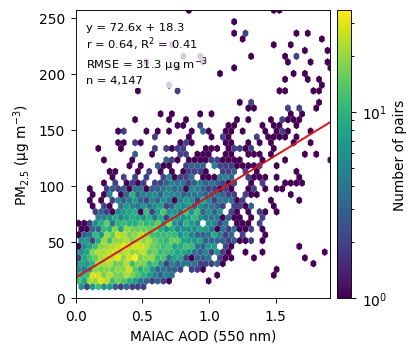

In [6]:
fig, ax = plt.subplots(figsize=(3.6, 3.4))
x_line = np.array([0, np.percentile(x, 99.5)])
hb = ax.hexbin(x, y, gridsize=45, cmap="viridis", mincnt=1, bins="log", linewidths=0,
               extent=(0, x_line[1], 0, np.percentile(y, 99.5)))
ax.plot(x_line, fit.intercept + fit.slope * x_line, color="#d7191c", linewidth=1.3)

ax.text(0.04, 0.96,
        f"y = {fit.slope:.1f}x + {fit.intercept:.1f}\n"
        f"r = {fit.rvalue:.2f}, R$^2$ = {fit.rvalue ** 2:.2f}\n"
        f"RMSE = {rmse:.1f} {UNIT}\nn = {len(x):,}",
        transform=ax.transAxes, va="top", fontsize=7.5,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2))
ax.set_xlim(0, x_line[1]); ax.set_ylim(0, np.percentile(y, 99.5))
ax.set_xlabel("MAIAC AOD (550 nm)"); ax.set_ylabel(f"PM$_{{2.5}}$ ({UNIT})")
fig.colorbar(hb, ax=ax, pad=0.02, label="Number of pairs")
save_fig(fig, "fig07_scatter_all")
plt.show()

## 4. ความสัมพันธ์ต่างกันตามภาคหรือไม่

เขียนฟังก์ชันเล็ก ๆ คำนวณสถิติชุดเดิม เพื่อใช้ซ้ำกับกลุ่มข้อมูลใดก็ได้

In [7]:
def fit_stats(df):
    # คืนสถิติของเส้นถดถอย PM2.5 ~ AOD สำหรับตารางที่ส่งเข้ามา
    f = stats.linregress(df["aod_055"], df["pm25"])
    pred = f.intercept + f.slope * df["aod_055"]
    return pd.Series({
        "n": len(df), "r": f.rvalue, "R2": f.rvalue ** 2,
        "slope": f.slope, "intercept": f.intercept,
        "RMSE": np.sqrt(np.mean((df["pm25"] - pred) ** 2)),
    })

by_region = pairs.groupby("region").apply(fit_stats)
by_region.round(2)

,n,r,R2,slope,intercept,RMSE
region,,,,,,
Central,1594.0,0.30,0.09,29.42,36.41,24.10
East,454.0,0.32,0.10,21.78,30.85,15.13
North,1079.0,0.70,0.49,88.09,20.86,41.22
Northeast,586.0,0.40,0.16,30.42,34.31,21.90
South,185.0,0.51,0.26,25.86,15.00,6.20
West,249.0,0.46,0.21,45.70,28.37,22.83


### ภาพที่ 2 — Scatter plot รายภาค

บันทึกแล้ว: figures/fig08_scatter_by_region.png และ .pdf


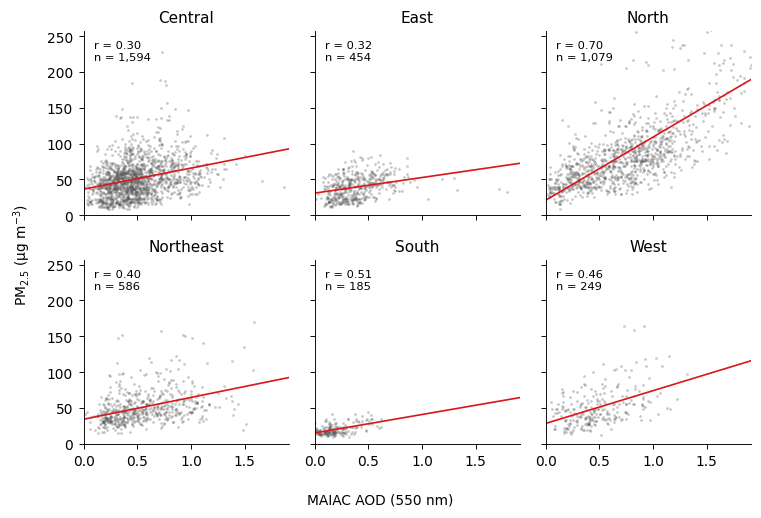

In [8]:
regions = list(by_region.index)
ncols = 3; nrows = int(np.ceil(len(regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7.0, 2.35 * nrows), sharex=True, sharey=True)
x_max, y_max = np.percentile(x, 99.5), np.percentile(y, 99.5)

for ax, region in zip(axes.ravel(), regions):
    sub = pairs[pairs["region"] == region]; s = by_region.loc[region]
    ax.scatter(sub["aod_055"], sub["pm25"], s=3, color="0.35", alpha=0.35, linewidths=0)
    ax.plot([0, x_max], [s["intercept"], s["intercept"] + s["slope"] * x_max], color="#d7191c", linewidth=1.1)
    ax.set_title(region)
    ax.text(0.05, 0.95, f"r = {s['r']:.2f}\nn = {int(s['n']):,}", transform=ax.transAxes, va="top", fontsize=7.5)
    ax.set_xlim(0, x_max); ax.set_ylim(0, y_max)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.ravel()[len(regions):]:
    ax.set_visible(False)
fig.supxlabel("MAIAC AOD (550 nm)", fontsize=9); fig.supylabel(f"PM$_{{2.5}}$ ({UNIT})", fontsize=9)
fig.tight_layout()
save_fig(fig, "fig08_scatter_by_region")
plt.show()

> 💭 **ลองคิด** — ภาคใด $r$ สูงที่สุด ภาคใดต่ำที่สุด ลองเชื่อมกับแหล่งกำเนิดฝุ่นหลักของแต่ละภาค

## 5. ความสัมพันธ์รายสถานี

คำนวณ $r$ ของแต่ละสถานี โดยใช้เฉพาะสถานีที่มีอย่างน้อย 15 คู่ เพราะ $r$ จากข้อมูลน้อยไม่น่าเชื่อถือ

### ภาพที่ 3 — แผนที่ค่า $r$ รายสถานี

บันทึกแล้ว: figures/fig09_station_r_map.png และ .pdf


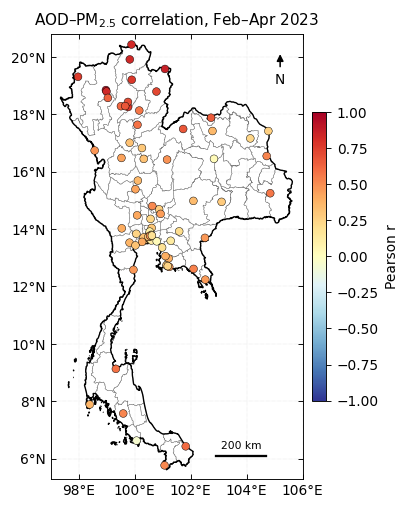

สถานีที่แสดง: 80 | ค่ามัธยฐานของ r: 0.4


In [9]:
MIN_PAIRS = 15

by_station = pairs.groupby(["station", "lat", "lon"]).filter(lambda d: len(d) >= MIN_PAIRS) \
                  .groupby(["station", "lat", "lon"]).apply(fit_stats).reset_index()

fig, ax = plt.subplots(figsize=(3.6, 6.2))
base_map(ax, f"AOD–PM$_{{2.5}}$ correlation, Feb–Apr {YEAR}")
sc = ax.scatter(by_station["lon"], by_station["lat"], c=by_station["r"], cmap="RdYlBu_r",
                vmin=-1, vmax=1, s=26, edgecolor="black", linewidth=0.3, zorder=6)
fig.colorbar(sc, ax=ax, shrink=0.55, pad=0.03, label="Pearson r")
save_fig(fig, "fig09_station_r_map")
plt.show()

print("สถานีที่แสดง:", len(by_station), "| ค่ามัธยฐานของ r:", round(by_station["r"].median(), 2))

## 6. สรุป

```
r สูง            ≠  AOD เป็น "สาเหตุ" ของ PM2.5   (ทั้งคู่เป็นผลของละอองลอยชุดเดียวกัน)
เส้นตรงเส้นเดียว   ≠  ใช้ได้ทุกภาค                 (slope ต่างกันตามพื้นที่)
R² ที่เหลือ        =  สิ่งที่ AOD อย่างเดียวอธิบายไม่ได้
```

ส่วนที่อธิบายไม่ได้มาจากความสูงชั้นผสม ความชื้น ชนิดของละอองลอย และตำแหน่งที่ตั้ง
Notebook 04 จะใช้ **Random Forest** ซึ่งรับตัวแปรได้หลายตัวและไม่บังคับให้ความสัมพันธ์เป็นเส้นตรง

---
## แบบฝึกหัด

### ข้อ 1 (ฝึกทำ) — คำนวณ $r$ ด้วยมือ
ใช้ข้อมูล 5 คู่ด้านล่าง คำนวณ $r$ ตามสมการในหัวข้อ 1.1 ทีละขั้น โดยไม่ใช้ฟังก์ชันสำเร็จรูป

In [10]:
aod_5 = np.array([0.20, 0.45, 0.60, 0.90, 1.30])
pm_5 = np.array([22.0, 41.0, 38.0, 70.0, 95.0])

# เขียนโค้ดของคุณที่นี่
# แนวทาง: dx = aod_5 - aod_5.mean()   dy = pm_5 - pm_5.mean()
#         ตัวเศษ = (dx * dy).sum()     ตัวส่วน = sqrt((dx**2).sum()) * sqrt((dy**2).sum())

my_r = None

In [11]:
#@title ตรวจคำตอบข้อ 1 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
_expected = np.corrcoef(aod_5, pm_5)[0, 1]
if my_r is None:
    print("ยังไม่ได้ใส่คำตอบใน my_r")
elif abs(my_r - _expected) < 0.005:
    print("ถูกต้อง ตรงกับ np.corrcoef")
else:
    print("ยังไม่ใช่ ตรวจว่าลบค่าเฉลี่ยออกก่อนคูณ และถอดรากที่ตัวส่วนครบทั้งสองพจน์")

ยังไม่ได้ใส่คำตอบใน my_r


In [12]:
#@title เฉลยข้อ 1 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
dx = aod_5 - aod_5.mean()
dy = pm_5 - pm_5.mean()
numerator = (dx * dy).sum()
denominator = np.sqrt((dx ** 2).sum()) * np.sqrt((dy ** 2).sum())
print(f"ตัวเศษ = {numerator:.3f} | ตัวส่วน = {denominator:.3f} | r = {numerator / denominator:.3f}")
print(f"ตรวจด้วย np.corrcoef: {np.corrcoef(aod_5, pm_5)[0, 1]:.3f}")

ตัวเศษ = 48.610 | ตัวส่วน = 49.420 | r = 0.984
ตรวจด้วย np.corrcoef: 0.984


### ข้อ 2 (ฝึกคิด) — Pearson กับ Spearman
Pearson วัดความสัมพันธ์ **เชิงเส้น** และไวต่อค่าสุดโต่ง ส่วน Spearman ($\rho$) ใช้ **อันดับ** ของข้อมูลแทนค่าจริง
คำนวณทั้งสองค่าสำหรับชุด `pairs` ทั้งหมด แล้วเปรียบเทียบ

In [13]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: stats.pearsonr(x, y)   และ   stats.spearmanr(x, y)

In [14]:
#@title เฉลยข้อ 2 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
r_pearson = stats.pearsonr(pairs["aod_055"], pairs["pm25"])[0]
r_spearman = stats.spearmanr(pairs["aod_055"], pairs["pm25"])[0]
print(f"Pearson r = {r_pearson:.2f} | Spearman rho = {r_spearman:.2f}")

Pearson r = 0.64 | Spearman rho = 0.56


<details>
<summary><b>คำอธิบายข้อ 2</b> (คลิกเพื่อเปิด)</summary>

- ถ้า Pearson **สูงกว่า** Spearman (กรณีของข้อมูลปี 2023) แสดงว่ามีกลุ่มค่าสูงมากที่เรียงตัวตามแนวเส้นตรงและดึง $r$ ขึ้น
  ในที่นี้คือวันหมอกควันรุนแรงของภาคเหนือ ซึ่งทั้ง AOD และ PM2.5 สูงพร้อมกัน เมื่อดูเฉพาะ "อันดับ" ความสัมพันธ์ในข้อมูลส่วนใหญ่ที่ค่าต่ำถึงปานกลางจึงอ่อนกว่าที่ $r$ บอก
- ถ้า Spearman **สูงกว่า** Pearson แสดงว่าความสัมพันธ์เป็นแบบ "เพิ่มตามกัน" แต่ **ไม่เป็นเส้นตรง** หรือมีค่าสุดโต่งดึง Pearson ลง
- ถ้าใกล้เคียงกัน แสดงว่าเส้นตรงเป็นคำอธิบายที่พอใช้ได้

ข้อคิด: $r$ ทั้งประเทศค่าเดียวอาจสะท้อนเหตุการณ์รุนแรงของภาคเดียว จึงต้องดูรายภาคและรายสถานีประกอบเสมอ

</details>

### ข้อ 3 (ฝึกคิด) — ผลสรุปไวต่อเกณฑ์คุณภาพหรือไม่
คำนวณ $r$ ทั้งประเทศใหม่ เมื่อใช้เกณฑ์ `aod_n_pixels` อย่างน้อย 1, 3, 5 และ 7 พร้อมจำนวนคู่ที่เหลือ

In [15]:
# เขียนโค้ดของคุณที่นี่
# แนวทาง: เริ่มจาก both = m.dropna(subset=["pm25", "aod_055"]) แล้ววนลูปกรองทีละเกณฑ์ ใช้ฟังก์ชัน fit_stats

In [16]:
#@title เฉลยข้อ 3 (ลองทำเองก่อน แล้วดับเบิลคลิกเพื่อดูโค้ด)
both = m.dropna(subset=["pm25", "aod_055"])
pd.DataFrame({k: fit_stats(both[both["aod_n_pixels"] >= k]) for k in [1, 3, 5, 7]}).T[["n", "r", "RMSE"]].round(2)

,n,r,RMSE
1,4434.0,0.63,31.03
3,4147.0,0.64,31.27
5,3898.0,0.65,31.44
7,3697.0,0.66,31.46


<details>
<summary><b>คำอธิบายข้อ 3</b> (คลิกเพื่อเปิด)</summary>

นี่คือ **sensitivity analysis** อย่างง่าย ถ้า $r$ เปลี่ยนเพียงเล็กน้อยเมื่อเกณฑ์เปลี่ยน ผลสรุปถือว่ามั่นคง (robust)
ถ้าเปลี่ยนมาก ต้องรายงานและอภิปรายในบทความ ไม่ควรเลือกเฉพาะเกณฑ์ที่ให้ค่าดีที่สุด

</details>

### ข้อ 4 (ฝึกตีความ)
intercept ($\beta_0$) ของเส้นถดถอยทั้งประเทศไม่เท่ากับศูนย์ หมายความว่าอย่างไรในทางกายภาพ
และเหตุใด slope ของแต่ละภาคจึงไม่เท่ากัน

<details>
<summary><b>แนวคำตอบข้อ 4</b> (คลิกเพื่อเปิด)</summary>

**intercept เป็นบวก** — แม้ดาวเทียมวัด AOD ได้ใกล้ศูนย์ สถานียังวัดฝุ่นได้ระดับหนึ่ง เพราะมีฝุ่นที่สะสมใกล้พื้นในชั้นบาง ๆ
(เช่น จากการจราจรตอนเช้าและกลางคืน) ซึ่งส่งผลต่อค่าเฉลี่ย 24 ชั่วโมง แต่มีผลต่อ AOD ทั้งคอลัมน์ตอนกลางวันน้อย
อีกส่วนหนึ่งเป็นผลทางสถิติจาก noise ใน AOD ซึ่งทำให้ slope ต่ำลงและ intercept สูงขึ้น

**slope ต่างกัน** — slope คือ "PM2.5 ต่อ AOD หนึ่งหน่วย" ซึ่งขึ้นกับว่าละอองลอยกระจายตัวในแนวดิ่งอย่างไร
- ชั้นผสมตื้น ฝุ่นอัดใกล้พื้น → slope สูง
- ควันลอยสูงหรือชั้นผสมหนา → slope ต่ำ
- ความชื้นสูง (ใกล้ทะเล) อนุภาคพองตัว AOD เพิ่มโดยมวลไม่เพิ่ม → slope ต่ำ

</details>

### ต่อยอดสำหรับ ป.โท
ข้อมูลชุดนี้เป็นการวัดซ้ำจากสถานีเดิมหลายวัน ค่าในสถานีเดียวกันจึงไม่เป็นอิสระต่อกัน
ให้ค้นคว้า **linear mixed-effects model** (เช่น random intercept และ random slope รายวัน ตามแนวของ Lee et al., 2011)
แล้วอธิบายว่าต่างจากเส้นถดถอยเส้นเดียวอย่างไร

*แนวทาง* — ลองใช้ `statsmodels.formula.api.mixedlm("pm25 ~ aod_055", pairs, groups=pairs["date"], re_formula="~aod_055")`
แนวคิดคือ ความสัมพันธ์ AOD–PM2.5 เปลี่ยนไปทุกวันตามสภาพอากาศ จึงยอมให้แต่ละวันมี slope และ intercept ของตัวเอง